In [1]:
# 卷积以及下采样叫做特征提取   卷积运算 从input经过一些列的运算得到output 
# 分为两步特征提取以及分类

import torch
in_channels,out_channels = 5,10
width, height = 100,100
kernel_size = 3
batch_size = 1

input = torch.randn(batch_size,
                    in_channels,
                    width,
                    height)
conv_layer  = torch.nn.Conv2d(in_channels,
                              out_channels,
                              kernel_size=kernel_size)

output = conv_layer(input)

print(input.shape)
print(output.shape)
print(conv_layer.weight.shape)

torch.Size([1, 5, 100, 100])
torch.Size([1, 10, 98, 98])
torch.Size([10, 5, 3, 3])


In [ ]:
import torch
input = [
    3,4,5,6,7,
    2,4,6,8,2,
    1,6,7,8,4,
    9,7,4,6,2,
    3,7,5,4,1
]
# 下采样

input  = torch.Tensor(input).view(1,1,5,5)
conv_layer = torch.nn.Conv2d(1,1,kernel_size=3,padding=1,bias=False)
kernel = torch.Tensor([1,2,3,4,5,6,7,8,9]).view(1,1,3,3)
conv_layer.weight.data = kernel.data
output = conv_layer(input)
print(output)

tensor([[[[ 91., 162., 225., 216., 131.],
          [114., 208., 296., 263., 150.],
          [192., 259., 282., 214., 122.],
          [194., 251., 253., 169.,  86.],
          [ 96., 112., 110.,  68.,  31.]]]], grad_fn=<ConvolutionBackward0>)


In [3]:
import torch
input = [
    3,4,5,6,7,
    2,4,6,8,2,
    1,6,7,8,4,
    9,7,4,6,2,
    3,7,5,4,1
]


input  = torch.Tensor(input).view(1,1,5,5)
conv_layer = torch.nn.Conv2d(1,1,kernel_size=3,stride=2,bias=False)
kernel = torch.Tensor([1,2,3,4,5,6,7,8,9]).view(1,1,3,3)
conv_layer.weight.data = kernel.data
output = conv_layer(input)
print(output)

tensor([[[[208., 263.],
          [251., 169.]]]], grad_fn=<ConvolutionBackward0>)


In [ ]:
import torch
input = [
    3,4,5,6,
    2,4,6,8,
    1,6,7,4,
    9,7,4,2
]


input  = torch.Tensor(input).view(1,1,4,4)
maxpooling_layer = torch.nn.AvgPool2d(kernel_size=2,padding=1)
# maxpooling_layer = F.avg_pool2d(x,kernel_size=3,stride=1,padding=1)
output = maxpooling_layer(input)
print(output)

RuntimeError: input image (T: 1 H: 4 W: 4) smaller than kernel size (kT: 2 kH: 2 kW: 2)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super(Net, self).__init__()
        # 卷积层部分
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)  # 增加通道数，添加padding保持尺寸
        self.bn1 = nn.BatchNorm2d(32)  # 添加BatchNorm
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)  # 增加通道数
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # 添加额外卷积层
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pooling = nn.MaxPool2d(2)
        self.dropout = nn.Dropout2d(0.25)  # 卷积层后使用Dropout
        
        # 全连接层部分
        self.fc1 = nn.Linear(128 * 3 * 3, 256)  # 调整输入尺寸
        self.fc_bn1 = nn.BatchNorm1d(256)  # 全连接层的BatchNorm
        self.fc2 = nn.Linear(256, 128)
        self.fc_bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 10)
        
        self.dropout_fc = nn.Dropout(0.5)  # 全连接层使用更高的Dropout率
        
        # 初始化权重
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        batch_size = x.size(0)
        
        # 卷积层1
        x = self.pooling(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        
        # 卷积层2
        x = self.pooling(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        # 卷积层3
        x = self.pooling(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        
        # 展平
        x = x.view(batch_size, -1)
        
        # 全连接层
        x = F.relu(self.fc_bn1(self.fc1(x)))
        x = self.dropout_fc(x)
        
        x = F.relu(self.fc_bn2(self.fc2(x)))
        x = self.dropout_fc(x)
        
        x = self.fc3(x)
        
        return x

# 创建模型实例
model = Net()

# 打印模型结构
print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc_bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc_bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, b

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import requests
import gzip
import shutil

# ===== 1. 确保数据集存在 =====
def ensure_mnist_exists():
    # 创建正确的目录结构
    data_dir = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data', 'MNIST', 'raw')
    os.makedirs(data_dir, exist_ok=True)
    
    # 需要下载的文件列表
    files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]
    
    base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"
    
    for file in files:
        file_path = os.path.join(data_dir, file)
        extracted_path = file_path.replace('.gz', '')
        
        # 如果文件已存在则跳过
        if os.path.exists(extracted_path):
            continue
            
        # 下载文件
        print(f"下载 {file}...")
        response = requests.get(base_url + file)
        with open(file_path, 'wb') as f:
            f.write(response.content)
        
        # 解压文件
        print(f"解压 {file}...")
        with gzip.open(file_path, 'rb') as f_in:
            with open(extracted_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        
        # 删除压缩文件（可选）
        os.remove(file_path)

# 确保数据集存在
ensure_mnist_exists()

# ===== 2. 创建数据集加载器 =====
# 正确的数据路径
data_path = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data')

# 修正Normalize参数格式
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 注意这里是元组 (0.5,)
])

# 使用正确的数据集名称和参数语法
trainset = datasets.MNIST(  # 修正：MNIST 不是 WMIST
    data_path, 
    download=False,         # 修正：download=False 不是 download-False
    train=True, 
    transform=transform     # 修正：transform=transform 不是 transforms-transform
)

testset = datasets.MNIST(   # 修正：MNIST 不是 WMIST
    data_path, 
    download=False,         # 修正：download=False 不是 download-False
    train=False, 
    transform=transform     # 修正：transform=transform 不是 transforms-transform
)

# ===== 3. 可视化 =====
n = 10
plt.figure(figsize=(10, 5))
for i in range(n):
    image, label = trainset[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(image.squeeze().numpy(), cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch 
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn

# 1. 设置超参数
batch_size = 64

# 2. 定义数据转换
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # 修正逗号位置
])

# 3. 加载数据集 - 添加缺失的MNIST数据集定义
# 创建数据目录
import os
data_path = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data')
os.makedirs(data_path, exist_ok=True)

# 下载数据集
trainset = datasets.MNIST(
    data_path, 
    download=True, 
    train=True, 
    transform=transform
)

testset = datasets.MNIST(
    data_path, 
    download=True, 
    train=False, 
    transform=transform
)

# 4. 创建数据加载器
train_loader = DataLoader(
    dataset=trainset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    dataset=testset, 
    shuffle=False, 
    batch_size=batch_size
)


class Net(torch.nn.Module):
    def __init__(self, *args, **kwargs):
        super(Net,self).__init__()
        self.conv1 = torch.nn.Conv2d(1,10,kernel_size=5)
        self.conv2 = torch.nn.Conv2d(10,20,kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)
        self.fc =torch.nn.Linear(320,10)
    def forward(self,x):
        #Flatten data from (n,1,28,28) to (n,784)
        batch_size = x.size(0)
        x = F.relu(self.pooling(self.conv1(x)))
        x = F.relu(self.pooling(self.conv2(x)))
        x= x.view(batch_size,-1)
        x=self.fc(x)
        return x
model = Net()
device =torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 构造优化器与模型损失函数
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=0.01,momentum=0.5)
def train(epoch):
    running_loss = 0.0
    for batch_idx,data in enumerate(train_loader,0):
        inputs ,traget  =data
        inputs,target = inputs.to(device),target.to(device)
        optimizer.zero_gard()
        # forward + backward +update
        outputs = model(inputs)
        loss = criterion(outputs,target)
        loss.backward()
        optimizer.step()
        running_loss +=loss.item
        if batch_idx % 300 ==299:
            print('[%d,%5d] loss； %.3f' % (epoch +1, batch_idx+1,running_loss/2000))
            running_loss =0.0
def test():
    correct = 0
    total =0
    with torch.no_grad():
        for  data in test_loader:
            inputs,target =data
            inputs,target = inputs.to(device),target.to(device)
            outputs = model(input)
            _,predicted = torch.max(outputs.data,dim=1)
            total += target.size(0)
            correct +=(predicted==target).sum().item()
    print("accuracy on test set： %的%% [%d%d]" % (100*correct /total,correct,total))



AttributeError: 'function' object has no attribute 'size'

In [7]:
import torch
import torch 
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import os

# 1. 设置超参数
batch_size = 64

# 2. 定义数据转换
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # 修正逗号位置
])

# 3. 加载数据集
data_path = os.path.join(os.path.expanduser('~'), '.pytorch', 'MNIST_data')
os.makedirs(data_path, exist_ok=True)

# 下载数据集
trainset = datasets.MNIST(
    data_path, 
    download=True, 
    train=True, 
    transform=transform
)

testset = datasets.MNIST(
    data_path, 
    download=True, 
    train=False, 
    transform=transform
)

# 4. 创建数据加载器
train_loader = DataLoader(
    dataset=trainset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    dataset=testset, 
    shuffle=False, 
    batch_size=batch_size
)

class Net(torch.nn.Module):
    def __init__(self, *args, **kwargs):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(10, 20, kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)
        self.fc = torch.nn.Linear(320, 10)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = F.relu(self.pooling(self.conv1(x)))
        x = F.relu(self.pooling(self.conv2(x)))
        x = x.view(batch_size, -1)
        x = self.fc(x)
        return x

model = Net()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# 构造优化器与模型损失函数
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()  # 修正拼写错误
        # forward + backward + update
        outputs = model(inputs)
        loss = criterion(outputs, target)  # 修正变量名
        loss.backward()
        optimizer.step()
        running_loss += loss.item()  # 修正为loss.item()
        if batch_idx % 300 == 299:  # 修正变量名
            print('[%d, %5d] loss: %.3f' % (epoch + 1, batch_idx + 1, running_loss / 300))  # 修正除数和标点
            running_loss = 0.0

def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            inputs, target = data  # 修正变量名
            inputs, target = inputs.to(device), target.to(device)
            outputs = model(inputs)  # 修正变量名
            _, predicted = torch.max(outputs.data, dim=1)  # 修正语法
            total += target.size(0)
            correct += (predicted == target).sum().item()
    print("accuracy on test set: %.2f%% [%d/%d]" % (100 * correct / total, correct, total))  # 修正格式字符串

# 训练和测试循环
for epoch in range(10):
    train(epoch)
    test()

[1,   300] loss: 0.638
[1,   600] loss: 0.192
[1,   900] loss: 0.135
accuracy on test set: 96.88% [9688/10000]
[2,   300] loss: 0.109
[2,   600] loss: 0.092
[2,   900] loss: 0.082
accuracy on test set: 97.80% [9780/10000]
[3,   300] loss: 0.076
[3,   600] loss: 0.069
[3,   900] loss: 0.073
accuracy on test set: 98.36% [9836/10000]
[4,   300] loss: 0.060
[4,   600] loss: 0.065
[4,   900] loss: 0.057
accuracy on test set: 98.28% [9828/10000]
[5,   300] loss: 0.056
[5,   600] loss: 0.051
[5,   900] loss: 0.052
accuracy on test set: 98.59% [9859/10000]
[6,   300] loss: 0.048
[6,   600] loss: 0.048
[6,   900] loss: 0.048
accuracy on test set: 98.62% [9862/10000]
[7,   300] loss: 0.045
[7,   600] loss: 0.043
[7,   900] loss: 0.044
accuracy on test set: 98.66% [9866/10000]
[8,   300] loss: 0.042
[8,   600] loss: 0.039
[8,   900] loss: 0.042
accuracy on test set: 98.69% [9869/10000]
[9,   300] loss: 0.035
[9,   600] loss: 0.037
[9,   900] loss: 0.038
accuracy on test set: 98.54% [9854/10000]
[

使用设备: cuda
Files already downloaded and verified
Files already downloaded and verified
开始训练...
Epoch [1/10], Loss: 1.5598, Accuracy: 42.30%
Epoch [2/10], Loss: 1.1385, Accuracy: 59.15%
Epoch [3/10], Loss: 0.9558, Accuracy: 66.26%
Epoch [4/10], Loss: 0.8533, Accuracy: 70.12%
Epoch [5/10], Loss: 0.7889, Accuracy: 72.38%
Epoch [6/10], Loss: 0.7442, Accuracy: 74.29%
Epoch [7/10], Loss: 0.7069, Accuracy: 75.55%
Epoch [8/10], Loss: 0.6781, Accuracy: 76.46%
Epoch [9/10], Loss: 0.6566, Accuracy: 77.14%
Epoch [10/10], Loss: 0.6338, Accuracy: 78.15%
训练完成!
测试集准确率: 79.34%


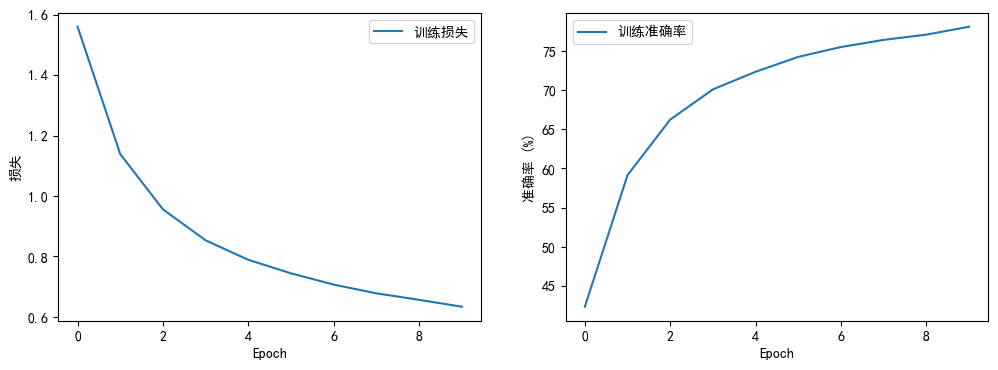

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


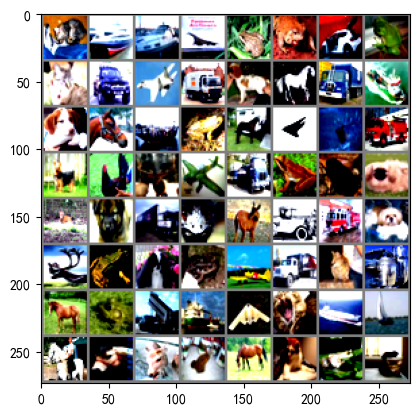

真实标签:  cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane deer  truck dog   bird  deer  plane truck frog  frog  dog   deer  dog   truck bird  deer  car   truck dog   deer  frog  dog   frog  plane truck cat   truck horse frog  truck ship  plane cat   ship  ship  horse horse deer  frog  horse cat   frog  cat  
预测结果:  cat   ship  ship  ship  frog  frog  cat   bird  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane deer  truck deer  bird  deer  plane truck frog  frog  dog   deer  cat   truck cat   deer  truck truck dog   plane frog  dog   frog  plane truck cat   truck horse bird  truck ship  horse cat   ship  ship  horse cat   cat   cat   horse dog   frog  cat  


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置设备（GPU如果可用）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 10



# 数据预处理与增强
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 加载CIFAR-10数据集
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                             download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                            download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

# CIFAR-10类别
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# 定义CNN模型
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(-1, 128 * 8 * 8)  # 展平
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# 初始化模型
model = CNN().to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练模型
train_losses = []
train_accuracies = []

print("开始训练...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print("训练完成!")

# 测试模型
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = 100. * correct / total
print(f'测试集准确率: {test_accuracy:.2f}%')

# 可视化训练过程
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失')
plt.xlabel('Epoch')
plt.ylabel('损失')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='训练准确率')
plt.xlabel('Epoch')
plt.ylabel('准确率 (%)')
plt.legend()
plt.show()

# 显示一些测试样本和预测结果
def imshow(img):
    img = img / 2 + 0.5  # 反归一化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 获取一些测试图像
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 显示图像
imshow(torchvision.utils.make_grid(images.cpu()))

# 打印预测结果
outputs = model(images)
_, predicted = torch.max(outputs, 1)

print('真实标签: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))
print('预测结果: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(batch_size)))

数据形状: (33, 15)
前几行数据:
        410       420       430       440       442       445       550  \
0  0.028050  0.028149  0.028609  0.029241  0.029530  0.029927  0.054046   
1  0.022730  0.022953  0.023600  0.024310  0.024591  0.024965  0.044315   
2  0.014804  0.015414  0.016159  0.016854  0.017245  0.017753  0.041939   
3  0.015378  0.015997  0.016807  0.017665  0.018034  0.018503  0.044519   
4  0.007881  0.008595  0.009477  0.010262  0.010701  0.011169  0.028926   

        560       580       660       665       681       709       749  \
0  0.055293  0.051731  0.037496  0.035614  0.033040  0.034776  0.020482   
1  0.045124  0.042068  0.030098  0.028599  0.026606  0.027436  0.015890   
2  0.042786  0.039068  0.028932  0.026968  0.025259  0.028934  0.015709   
3  0.045858  0.042989  0.029476  0.027277  0.024937  0.027478  0.012317   
4  0.029233  0.026569  0.018186  0.016754  0.015581  0.017503  0.006819   

   叶绿素a[μg/L]  
0   35.154000  
1   28.627826  
2   41.728696  
3   28.64400

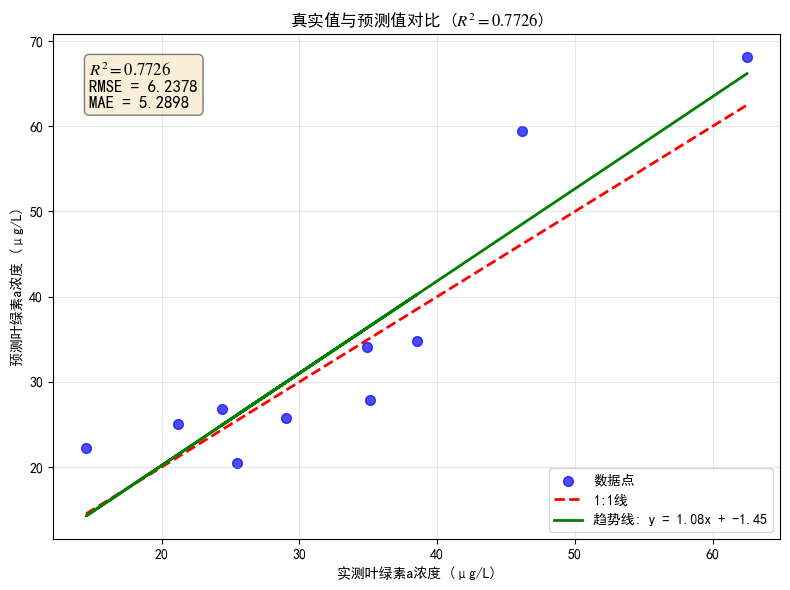

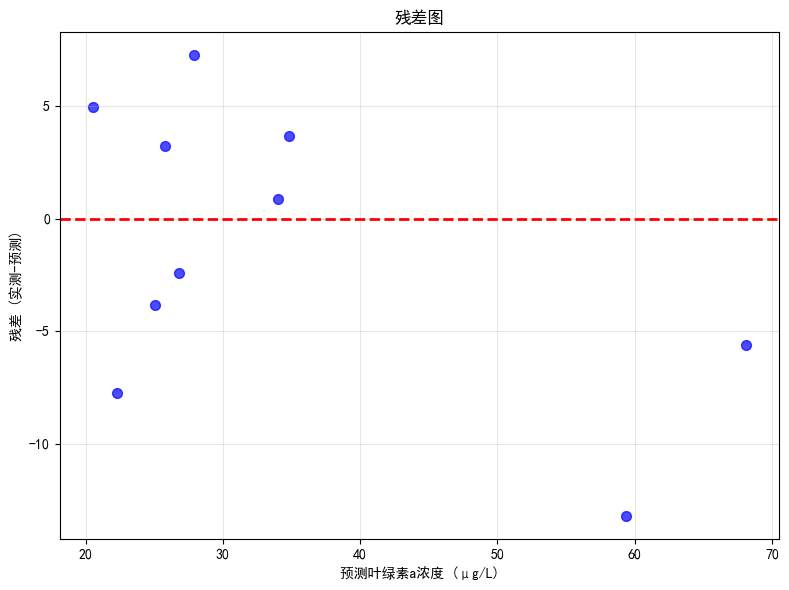

NameError: name 'feature_names' is not defined

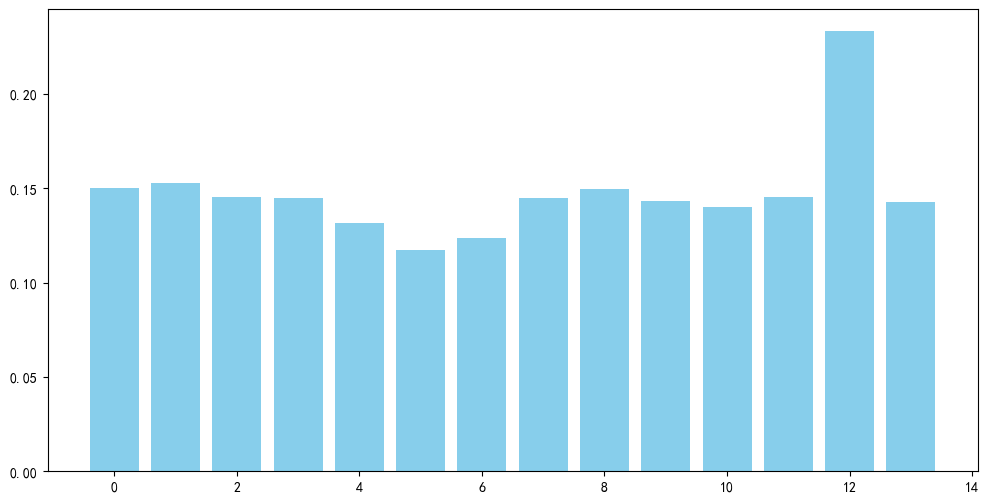

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.rcParams['mathtext.fontset'] = 'stix'  # 设置数学公式字体
# 设置随机种子以确保结果可重现
torch.manual_seed(42)
np.random.seed(42)

# 读取Excel文件
file_path = r"C:\Users\zyl\Desktop\zfxziliao\建模数据.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 检查数据
print("数据形状:", df.shape)
print("前几行数据:")
print(df.head())

# 分离特征和目标变量
X = df.iloc[:, :-1].values  # 所有波长数据列
y = df.iloc[:, -1].values   # 叶绿素a浓度列

print(f"特征形状: {X.shape}, 目标形状: {y.shape}")

# 数据标准化
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42
)

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# 创建数据加载器
batch_size = 8
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 定义神经网络模型
class ChlorophyllModel(nn.Module):
    def __init__(self, input_size):
        super(ChlorophyllModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# 初始化模型
input_size = X_train.shape[1]
model = ChlorophyllModel(input_size)
print(model)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X).flatten()
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    train_losses.append(epoch_train_loss / len(train_loader))
    
    # 验证阶段
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor).flatten()
        test_loss = criterion(test_predictions, y_test_tensor)
        test_losses.append(test_loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

# 评估模型
model.eval()
with torch.no_grad():
    # 对测试集进行预测
    y_pred_scaled = model(X_test_tensor).numpy().flatten()
    
    # 反标准化预测值
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # 计算评估指标
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f'R² Score: {r2:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')

# 绘制训练和测试损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Testing Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 绘制真实值与预测值的散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.title(f'真实值与预测值对比 ($R^2 = {r2:.4f}$)')
plt.grid(True)
plt.show()

# 绘制残差图
residuals = y_true - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

# 绘制特征重要性（使用简单的权重分析）
# 获取第一层权重
first_layer_weights = model.model[0].weight.data.numpy()
feature_importance = np.mean(np.abs(first_layer_weights), axis=0)

# 获取波长名称
wavelengths = df.columns[:-1].tolist()

# 绘制特征重要性
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xticks(range(len(wavelengths)), wavelengths, rotation=45)
plt.xlabel('Wavelengths')
plt.ylabel('Feature Importance')
plt.title('Feature Importance Based on First Layer Weights')
plt.tight_layout()
plt.show()

# 保存模型
torch.save(model.state_dict(), 'chlorophyll_model.pth')
print("模型已保存为 chlorophyll_model.pth")

拟合的参数: a = -71.7605, b = 88.1541, c = 17.9151
测试集评估指标:
R²: -1.9978
RMSE: 22.6481
MAE: 16.4822


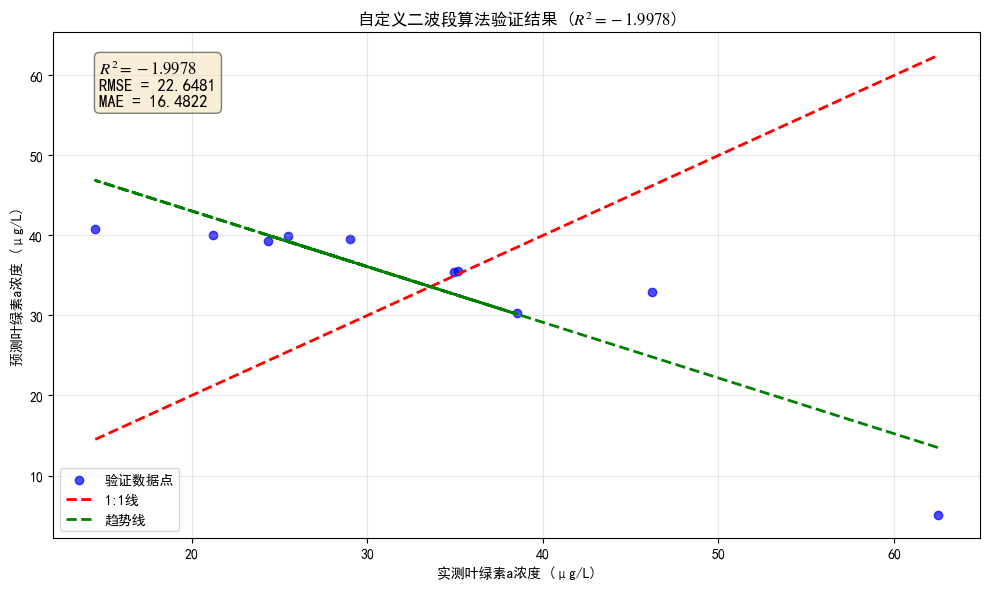

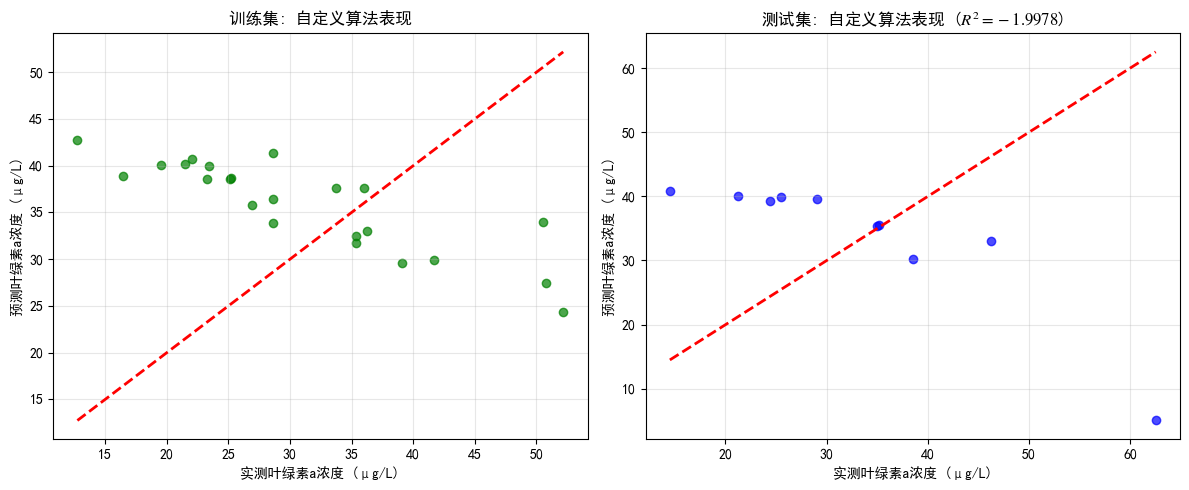

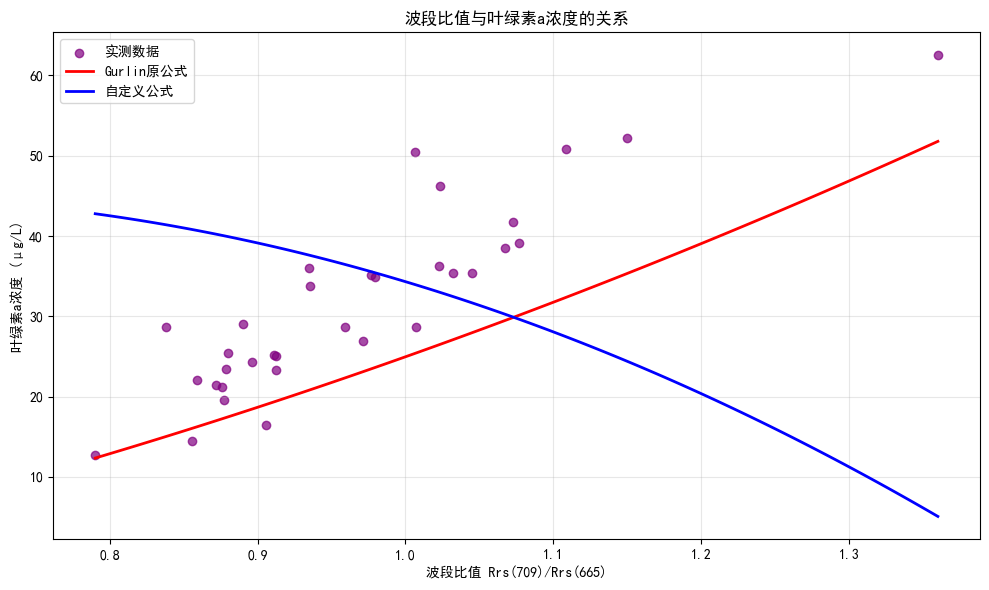


模型性能摘要:
训练集样本数: 23
测试集样本数: 10
自定义公式: Chla = -71.7605 × (Rrs709/Rrs665)² + 88.1541 × (Rrs709/Rrs665) + 17.9151
测试集R²: -1.9978
测试集RMSE: 22.6481 μg/L
测试集MAE: 16.4822 μg/L

原Gurlin公式性能:
R²: 0.3645
RMSE: 10.4274 μg/L
MAE: 9.2858 μg/L

性能提升:
R² 提升: -648.03%
RMSE 降低: -117.20%
MAE 降低: -77.50%


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = r"C:\Users\zyl\Desktop\zfxziliao\建模数据.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 提取665nm和709nm波段的反射率数据
band_665 = df.iloc[:, 10].values
band_709 = df.iloc[:, 12].values
chla = df.iloc[:, -1].values  # 叶绿素a浓度列

# 计算波段比值
ratio = band_709 / band_665

# 划分数据集：70%建模，30%验证
X_train, X_test, y_train, y_test = train_test_split(
    ratio, chla, test_size=0.3, random_state=42
)

# 准备多项式特征 (二次多项式)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_test_poly = poly.transform(X_test.reshape(-1, 1))

# 使用线性回归拟合二次多项式模型
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 获取拟合的参数
a, b, c = model.coef_[1], model.coef_[2], model.intercept_
print(f"拟合的参数: a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")

# 定义新的二波段算法公式
def customized_algorithm(ratio):
    """根据实测数据拟合的二波段算法"""
    return a * ratio**2 + b * ratio + c

# 在训练集上应用算法
y_pred_train = customized_algorithm(X_train)

# 在测试集上应用算法
y_pred_test = customized_algorithm(X_test)

# 计算评估指标
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)

print(f'测试集评估指标:')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

# 绘制验证集的散点图
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='blue', label='验证数据点')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1线')

# 添加趋势线
z = np.polyfit(y_test, y_pred_test, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g--", lw=2, label='趋势线')

plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'自定义二波段算法验证结果 ($R^2 = {r2:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

# 添加评估指标文本框
textstr = f'$R^2 = {r2:.4f}$\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# 绘制训练集和测试集的对比
plt.figure(figsize=(12, 5))

# 训练集
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.7, color='green')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title('训练集: 自定义算法表现')
plt.grid(True, alpha=0.3)

# 测试集
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'测试集: 自定义算法表现 ($R^2 = {r2:.4f}$)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制比值与叶绿素a浓度的关系
plt.figure(figsize=(10, 6))
plt.scatter(ratio, chla, alpha=0.7, color='purple', label='实测数据')

# 绘制Gurlin原公式曲线
x_range = np.linspace(min(ratio), max(ratio), 100)
y_gurlin = 25.28 * x_range**2 + 14.85 * x_range - 15.18
plt.plot(x_range, y_gurlin, 'r-', lw=2, label='Gurlin原公式')

# 绘制自定义公式曲线
y_custom = customized_algorithm(x_range)
plt.plot(x_range, y_custom, 'b-', lw=2, label='自定义公式')

plt.xlabel('波段比值 Rrs(709)/Rrs(665)')
plt.ylabel('叶绿素a浓度 (μg/L)')
plt.title('波段比值与叶绿素a浓度的关系')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出模型性能摘要
print("\n模型性能摘要:")
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
print(f"自定义公式: Chla = {a:.4f} × (Rrs709/Rrs665)² + {b:.4f} × (Rrs709/Rrs665) + {c:.4f}")
print(f"测试集R²: {r2:.4f}")
print(f"测试集RMSE: {rmse:.4f} μg/L")
print(f"测试集MAE: {mae:.4f} μg/L")

# 比较原公式和自定义公式的性能
# 使用原Gurlin公式计算预测值
y_pred_gurlin = 25.28 * X_test**2 + 14.85 * X_test - 15.18

# 计算原公式的评估指标
r2_gurlin = r2_score(y_test, y_pred_gurlin)
rmse_gurlin = np.sqrt(mean_squared_error(y_test, y_pred_gurlin))
mae_gurlin = mean_absolute_error(y_test, y_pred_gurlin)

print(f"\n原Gurlin公式性能:")
print(f"R²: {r2_gurlin:.4f}")
print(f"RMSE: {rmse_gurlin:.4f} μg/L")
print(f"MAE: {mae_gurlin:.4f} μg/L")

# 性能提升百分比
r2_improvement = ((r2 - r2_gurlin) / abs(r2_gurlin)) * 100
rmse_improvement = ((rmse_gurlin - rmse) / rmse_gurlin) * 100
mae_improvement = ((mae_gurlin - mae) / mae_gurlin) * 100

print(f"\n性能提升:")
print(f"R² 提升: {r2_improvement:.2f}%")
print(f"RMSE 降低: {rmse_improvement:.2f}%")
print(f"MAE 降低: {mae_improvement:.2f}%")

列名: [410, 420, 430, 440, 442, 445, 550, 560, 580, 660, 665, 681, 709, 749, '叶绿素a[μg/L]']
拟合的参数: a = 99.6088, b = -64.6219
拟合的公式: Chla = 99.6088 × (R708/R665) + -64.6219

测试集评估指标:
R²: 0.8604
RMSE: 4.8868
MAE: 4.0155


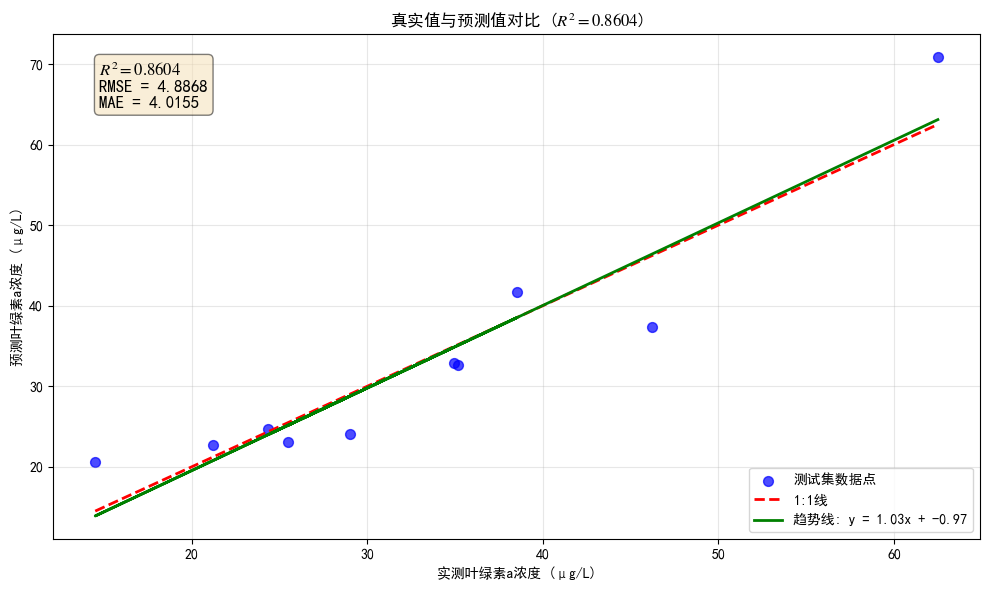

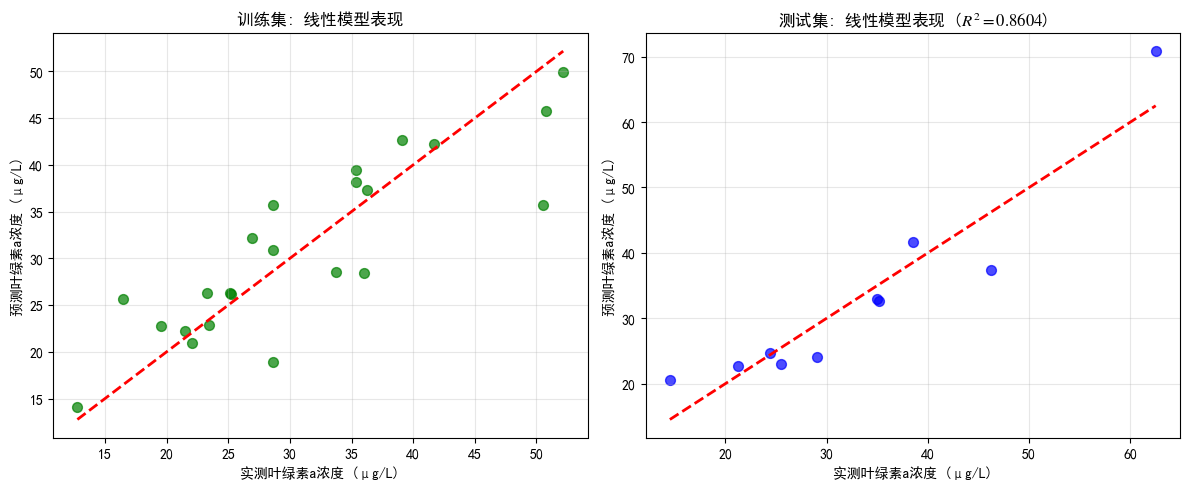

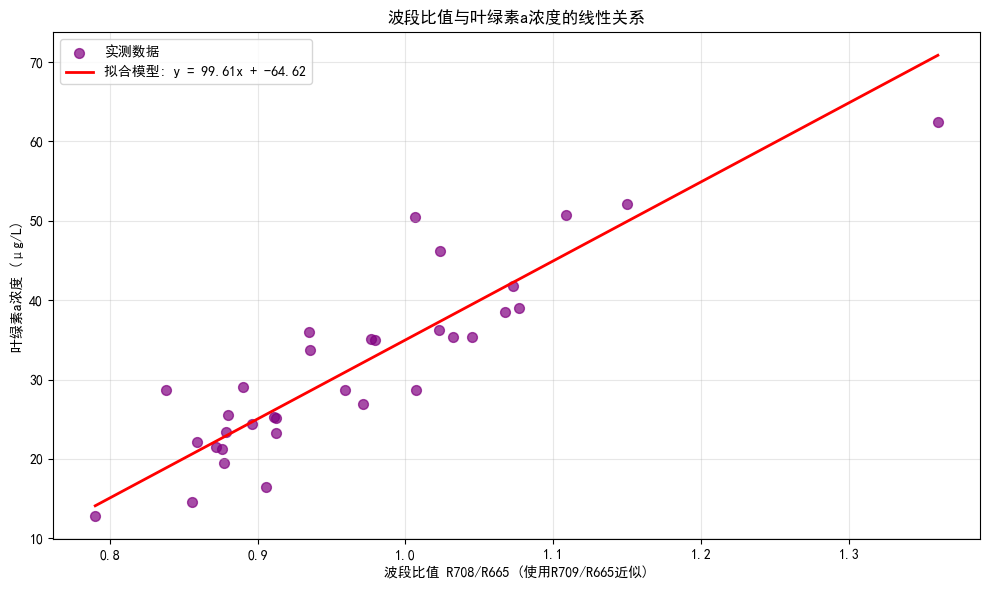

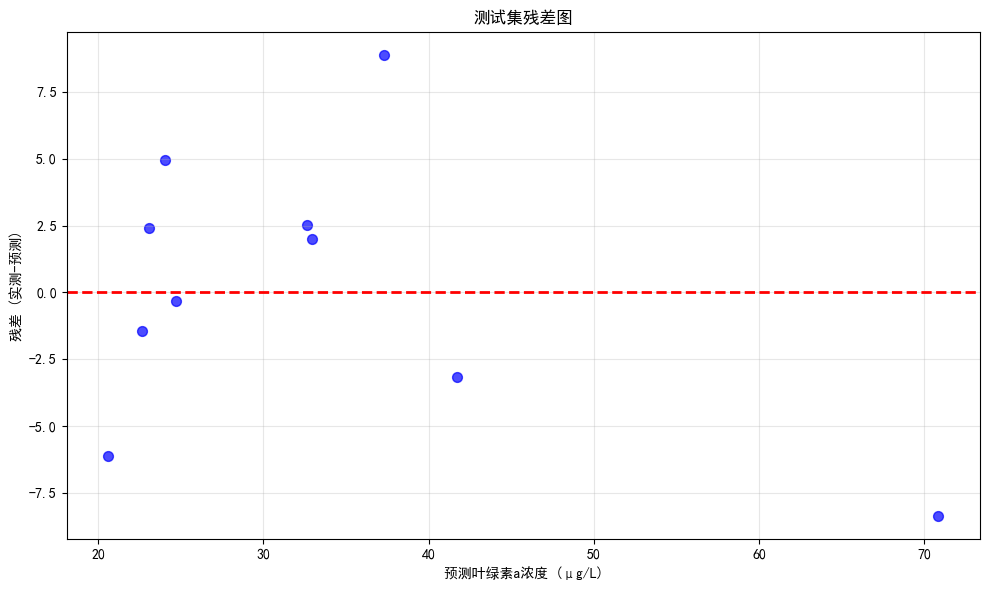


模型性能摘要:
训练集样本数: 23
测试集样本数: 10
拟合公式: Chla = 99.6088 × (R708/R665) + -64.6219
测试集R²: 0.8604
测试集RMSE: 4.8868 μg/L
测试集MAE: 4.0155 μg/L

原公式性能:
R²: 0.1048
RMSE: 12.3765 μg/L
MAE: 10.9999 μg/L

性能提升:
R² 提升: 721.25%
RMSE 降低: 60.52%
MAE 降低: 63.50%


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = r"C:\Users\zyl\Desktop\zfxziliao\建模数据.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 打印列名以查看实际列名
print("列名:", df.columns.tolist())

# 根据实际列名提取665nm和709nm波段的反射率数据
# 如果列名是数字，可能需要转换为字符串进行比较
band_665_col = None
band_709_col = None  # 使用709nm近似708nm

for col in df.columns:
    if str(col).strip() == '665':
        band_665_col = col
    elif str(col).strip() == '709':  # 使用709nm作为708nm的近似
        band_709_col = col

# 如果找不到指定列名，尝试使用列索引
if band_665_col is None or band_709_col is None:
    print("警告: 未找到名为'665'或'709'的列，尝试使用列索引")
    # 假设665nm在第10列，709nm在第12列（从0开始计数）
    band_665 = df.iloc[:, 10].values  # 第11列
    band_709 = df.iloc[:, 12].values  # 第13列
else:
    band_665 = df[band_665_col].values
    band_709 = df[band_709_col].values

chla = df.iloc[:, -1].values  # 叶绿素a浓度列

# 计算波段比值 (使用709nm作为708nm的近似)
ratio = band_709 / band_665

# 划分数据集：70%训练，30%测试
X_train, X_test, y_train, y_test = train_test_split(
    ratio.reshape(-1, 1), chla, test_size=0.3, random_state=42
)

# 使用线性回归拟合模型
model = LinearRegression()
model.fit(X_train, y_train)

# 获取拟合的参数
a = model.coef_[0]
b = model.intercept_
print(f"拟合的参数: a = {a:.4f}, b = {b:.4f}")
print(f"拟合的公式: Chla = {a:.4f} × (R708/R665) + {b:.4f}")

# 在测试集上进行预测
y_pred = model.predict(X_test)

# 计算评估指标
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'\n测试集评估指标:')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

# 绘制测试集的预测结果
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', s=50, label='测试集数据点')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1线')

# 添加趋势线
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g-", lw=2, label=f'趋势线: y = {z[0]:.2f}x + {z[1]:.2f}')

plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'真实值与预测值对比 ($R^2 = {r2:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

# 添加评估指标文本框
textstr = f'$R^2 = {r2:.4f}$\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# 绘制训练集和测试集的对比
plt.figure(figsize=(12, 5))

# 训练集
plt.subplot(1, 2, 1)
y_train_pred = model.predict(X_train)
plt.scatter(y_train, y_train_pred, alpha=0.7, color='green', s=50)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title('训练集: 线性模型表现')
plt.grid(True, alpha=0.3)

# 测试集
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'测试集: 线性模型表现 ($R^2 = {r2:.4f}$)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制比值与叶绿素a浓度的关系
plt.figure(figsize=(10, 6))
plt.scatter(ratio, chla, alpha=0.7, color='purple', s=50, label='实测数据')

# 绘制拟合的线性模型曲线
x_range = np.linspace(min(ratio), max(ratio), 100)
y_range = a * x_range + b
plt.plot(x_range, y_range, 'r-', lw=2, label=f'拟合模型: y = {a:.2f}x + {b:.2f}')

plt.xlabel('波段比值 R708/R665 (使用R709/R665近似)')
plt.ylabel('叶绿素a浓度 (μg/L)')
plt.title('波段比值与叶绿素a浓度的线性关系')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制残差图
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='blue', s=50)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('预测叶绿素a浓度 (μg/L)')
plt.ylabel('残差 (实测-预测)')
plt.title('测试集残差图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出模型性能摘要
print("\n模型性能摘要:")
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
print(f"拟合公式: Chla = {a:.4f} × (R708/R665) + {b:.4f}")
print(f"测试集R²: {r2:.4f}")
print(f"测试集RMSE: {rmse:.4f} μg/L")
print(f"测试集MAE: {mae:.4f} μg/L")

# 比较原公式和自定义公式的性能
# 使用原公式计算预测值
y_pred_original = 61.324 * X_test.flatten() - 37.94

# 计算原公式的评估指标
r2_original = r2_score(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_original = mean_absolute_error(y_test, y_pred_original)

print(f"\n原公式性能:")
print(f"R²: {r2_original:.4f}")
print(f"RMSE: {rmse_original:.4f} μg/L")
print(f"MAE: {mae_original:.4f} μg/L")

# 性能提升百分比
r2_improvement = ((r2 - r2_original) / abs(r2_original)) * 100 if r2_original != 0 else 0
rmse_improvement = ((rmse_original - rmse) / rmse_original) * 100 if rmse_original != 0 else 0
mae_improvement = ((mae_original - mae) / mae_original) * 100 if mae_original != 0 else 0

print(f"\n性能提升:")
print(f"R² 提升: {r2_improvement:.2f}%")
print(f"RMSE 降低: {rmse_improvement:.2f}%")
print(f"MAE 降低: {mae_improvement:.2f}%")

In [ ]:
# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 绘制真实值与预测值的散点图（修改为右图形式）
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.7, color='blue', s=50, label='数据点')

# 添加1:1线
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
         'r--', lw=2, label='1:1线')

# 添加趋势线
z = np.polyfit(y_true, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_true, p(y_true), "g-", lw=2, 
         label=f'趋势线: y = {z[0]:.2f}x + {z[1]:.2f}')

plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'真实值与预测值对比 ($R^2 = {r2:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

# 添加评估指标文本框
textstr = f'$R^2 = {r2:.4f}$\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# 绘制残差图（也改为中文）
residuals = y_true - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='blue', s=50)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('预测叶绿素a浓度 (μg/L)')
plt.ylabel('残差 (实测-预测)')
plt.title('残差图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制特征重要性（改为中文）
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance, color='skyblue')
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.xlabel('波长 (nm)')
plt.ylabel('特征重要性')
plt.title('基于第一层权重的特征重要性分析')
plt.tight_layout()
plt.show()

# 绘制训练和测试损失曲线（改为中文）
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='训练损失', color='blue')
plt.plot(test_losses, label='测试损失', color='red')
plt.title('训练和测试损失随迭代次数的变化')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

列名: [410, 420, 430, 440, 442, 445, 550, 560, 580, 660, 665, 681, 709, 749, '叶绿素a[μg/L]']
Moses模型拟合参数:
Chla = 99.6088 × (R708/R665) + -64.6219

Gilerson模型拟合参数:
Chla = [4.7089 × (R708/R665) + -0.7486]^2.567

Gurlin模型拟合参数:
Chla = 88.1541 × (R708/R665)^2 + -71.7605 × (R708/R665) + 17.9151

Moses模型测试集评估:
R²: 0.8604
RMSE: 4.8868
MAE: 4.0155

Gilerson模型测试集评估:
R²: 0.5769
RMSE: 8.5080
MAE: 5.7481

Gurlin模型测试集评估:
R²: 0.6319
RMSE: 7.9366
MAE: 5.5163


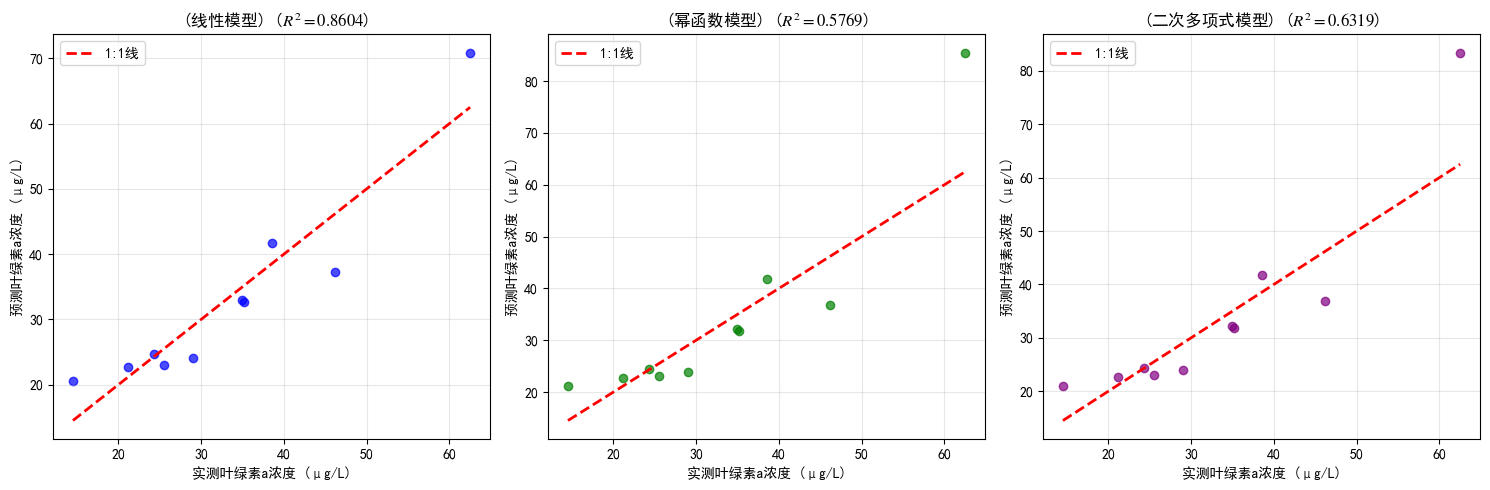

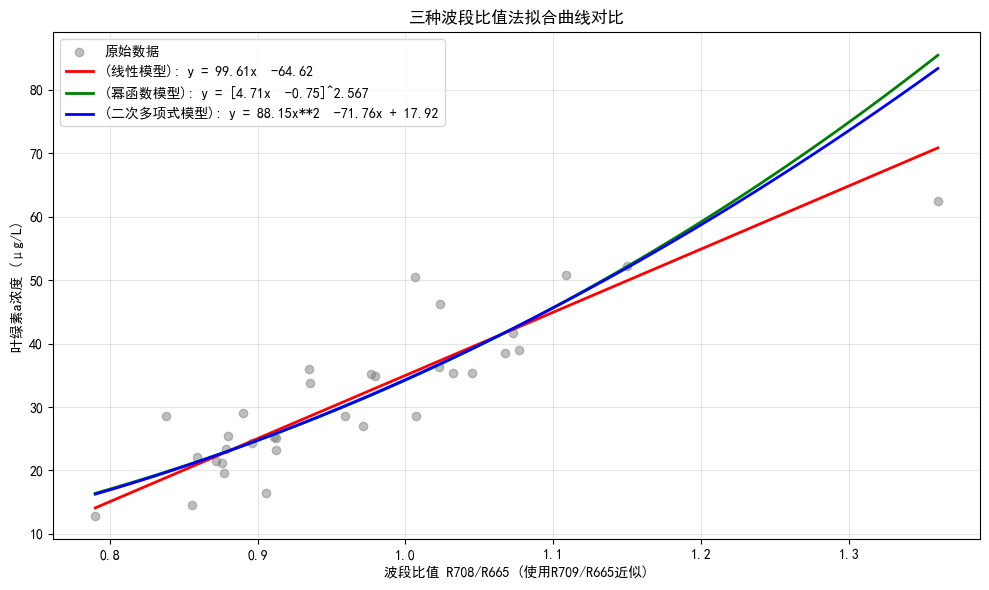

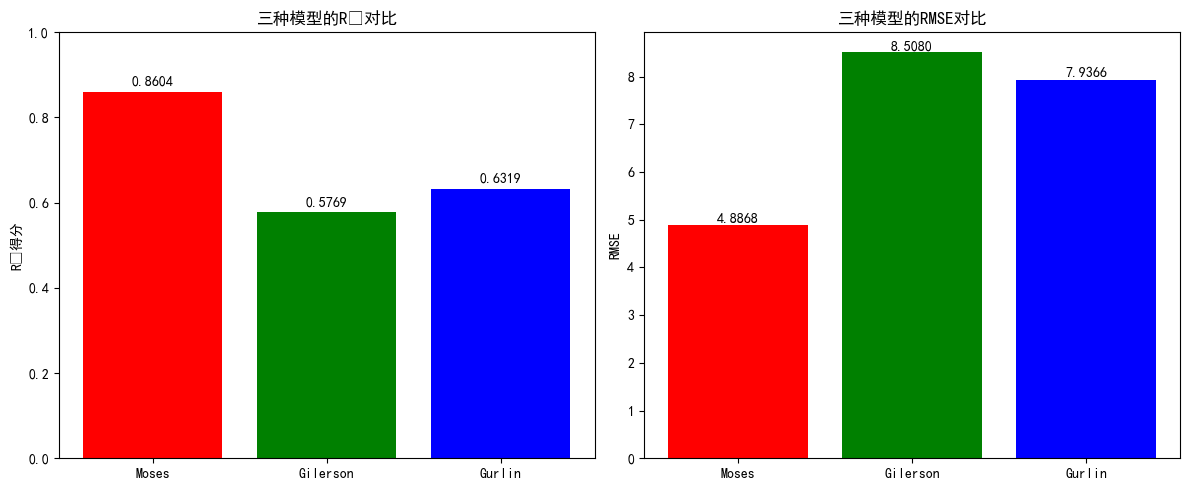


最佳模型: Moses模型
R²: 0.8604
RMSE: 4.8868


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取Excel文件
file_path = r"C:\Users\zyl\Desktop\zfxziliao\建模数据.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 打印列名以查看实际列名
print("列名:", df.columns.tolist())

# 根据实际列名提取665nm和709nm波段的反射率数据
# 使用709nm作为708nm的近似
band_665_col = None
band_709_col = None

for col in df.columns:
    if str(col).strip() == '665':
        band_665_col = col
    elif str(col).strip() == '709':  # 使用709nm作为708nm的近似
        band_709_col = col

# 如果找不到指定列名，尝试使用列索引
if band_665_col is None or band_709_col is None:
    print("警告: 未找到名为'665'或'709'的列，尝试使用列索引")
    # 假设665nm在第10列，709nm在第12列（从0开始计数）
    band_665 = df.iloc[:, 10].values  # 第11列
    band_709 = df.iloc[:, 12].values  # 第13列
else:
    band_665 = df[band_665_col].values
    band_709 = df[band_709_col].values

chla = df.iloc[:, -1].values  # 叶绿素a浓度列

# 计算波段比值 (使用709nm作为708nm的近似)
ratio = band_709 / band_665

# 划分数据集：70%训练，30%测试
X_train, X_test, y_train, y_test = train_test_split(
    ratio, chla, test_size=0.3, random_state=42
)

# 方法1: Moses线性模型 Chla = a * (R708/R665) + b
def fit_moses_model(X, y):
    """拟合Moses线性模型"""
    X_reshaped = X.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X_reshaped, y)
    a = model.coef_[0]
    b = model.intercept_
    return a, b, model

# 方法2: Gilerson幂函数模型 Chla = [a * (R708/R665) + b]^c
def gilerson_formula(x, a, b, c):
    """Gilerson模型公式"""
    return (a * x + b) ** c

def fit_gilerson_model(X, y):
    """拟合Gilerson幂函数模型"""
    # 使用非线性最小二乘法拟合
    try:
        # 提供初始参数猜测
        initial_guess = [35.75, -19.30, 1.124]  # 使用原文的参数作为初始猜测
        params, _ = curve_fit(gilerson_formula, X, y, p0=initial_guess, maxfev=5000)
        a, b, c = params
        
        # 定义预测函数
        def predict(X):
            return gilerson_formula(X, a, b, c)
            
        return a, b, c, predict
    except Exception as e:
        print(f"Gilerson模型拟合失败: {e}")
        # 使用线性近似作为备选方案
        X_reshaped = X.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X_reshaped, y)
        a = model.coef_[0]
        b = model.intercept_
        c = 1.0  # 设置c=1，退化为线性模型
        
        def predict(X):
            return a * X + b
            
        return a, b, c, predict

# 方法3: Gurlin二次多项式模型 Chla = a * (R708/R665)^2 + b * (R708/R665) + c
def fit_gurlin_model(X, y):
    """拟合Gurlin二次多项式模型"""
    # 准备多项式特征
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X.reshape(-1, 1))
    
    # 拟合多项式模型
    model = LinearRegression()
    model.fit(X_poly, y)
    
    a = model.coef_[2]  # 二次项系数
    b = model.coef_[1]  # 一次项系数
    c = model.intercept_  # 常数项
    
    # 定义预测函数
    def predict(X):
        X_poly = poly.transform(X.reshape(-1, 1))
        return model.predict(X_poly)
    
    return a, b, c, predict, poly

# 拟合三种模型
a_moses, b_moses, moses_model = fit_moses_model(X_train, y_train)
a_gilerson, b_gilerson, c_gilerson, gilerson_predict = fit_gilerson_model(X_train, y_train)
a_gurlin, b_gurlin, c_gurlin, gurlin_predict, poly_transformer = fit_gurlin_model(X_train, y_train)

# 打印拟合的参数
print("Moses模型拟合参数:")
print(f"Chla = {a_moses:.4f} × (R708/R665) + {b_moses:.4f}")

print("\nGilerson模型拟合参数:")
print(f"Chla = [{a_gilerson:.4f} × (R708/R665) + {b_gilerson:.4f}]^{c_gilerson:.3f}")

print("\nGurlin模型拟合参数:")
print(f"Chla = {a_gurlin:.4f} × (R708/R665)^2 + {b_gurlin:.4f} × (R708/R665) + {c_gurlin:.4f}")

# 在测试集上评估三种模型
def evaluate_model(y_true, y_pred, model_name):
    """评估模型并返回指标"""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{model_name}模型测试集评估:")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    return r2, rmse, mae

# Moses模型评估
y_pred_moses = moses_model.predict(X_test.reshape(-1, 1))
r2_moses, rmse_moses, mae_moses = evaluate_model(y_test, y_pred_moses, "Moses")

# Gilerson模型评估
y_pred_gilerson = gilerson_predict(X_test)
r2_gilerson, rmse_gilerson, mae_gilerson = evaluate_model(y_test, y_pred_gilerson, "Gilerson")

# Gurlin模型评估
y_pred_gurlin = gurlin_predict(X_test)
r2_gurlin, rmse_gurlin, mae_gurlin = evaluate_model(y_test, y_pred_gurlin, "Gurlin")

# 绘制三种模型的验证结果对比
plt.figure(figsize=(15, 5))

# Moses模型 (线性模型)
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_moses, alpha=0.7, color='blue')
# 添加1:1线
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1线')
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f' (线性模型) ($R^2 = {r2_moses:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gilerson模型 (幂函数模型)
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_gilerson, alpha=0.7, color='green')
# 添加1:1线
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1线')
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'(幂函数模型) ($R^2 = {r2_gilerson:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gurlin模型 (二次多项式模型)
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_gurlin, alpha=0.7, color='purple')
# 添加1:1线
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1线')
plt.xlabel('实测叶绿素a浓度 (μg/L)')
plt.ylabel('预测叶绿素a浓度 (μg/L)')
plt.title(f'(二次多项式模型) ($R^2 = {r2_gurlin:.4f}$)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制三种模型的拟合曲线对比
plt.figure(figsize=(10, 6))

# 生成x值范围
x_range = np.linspace(min(ratio), max(ratio), 100)

# 计算三种模型的预测值
y_moses_range = moses_model.predict(x_range.reshape(-1, 1))
y_gilerson_range = gilerson_predict(x_range)
y_gurlin_range = gurlin_predict(x_range)

# 绘制原始数据点
plt.scatter(ratio, chla, alpha=0.5, color='gray', label='原始数据')

# 绘制拟合曲线
plt.plot(x_range, y_moses_range, 'r-', lw=2, label=f'(线性模型): y = {a_moses:.2f}x  {b_moses:.2f}')
plt.plot(x_range, y_gilerson_range, 'g-', lw=2, label=f'(幂函数模型): y = [{a_gilerson:.2f}x  {b_gilerson:.2f}]^{c_gilerson:.3f}')
plt.plot(x_range, y_gurlin_range, 'b-', lw=2, label=f'(二次多项式模型): y = {a_gurlin:.2f}x**2  {b_gurlin:.2f}x + {c_gurlin:.2f}')

plt.xlabel('波段比值 R708/R665 (使用R709/R665近似)')
plt.ylabel('叶绿素a浓度 (μg/L)')
plt.title('三种波段比值法拟合曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制性能对比柱状图
models = ['Moses', 'Gilerson', 'Gurlin']
r2_scores = [r2_moses, r2_gilerson, r2_gurlin]
rmse_scores = [rmse_moses, rmse_gilerson, rmse_gurlin]

plt.figure(figsize=(12, 5))

# R²对比
plt.subplot(1, 2, 1)
bars = plt.bar(models, r2_scores, color=['red', 'green', 'blue'])
plt.ylabel('R²得分')
plt.title('三种模型的R²对比')
plt.ylim(0, 1)  # 限制y轴范围为0-1，确保R²为正数
# 在柱子上添加数值标签
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

# RMSE对比
plt.subplot(1, 2, 2)
bars = plt.bar(models, rmse_scores, color=['red', 'green', 'blue'])
plt.ylabel('RMSE')
plt.title('三种模型的RMSE对比')
# 在柱子上添加数值标签
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 输出最佳模型
best_model_idx = np.argmax(r2_scores)
best_model = models[best_model_idx]
best_r2 = r2_scores[best_model_idx]
best_rmse = rmse_scores[best_model_idx]

print(f"\n最佳模型: {best_model}模型")
print(f"R²: {best_r2:.4f}")
print(f"RMSE: {best_rmse:.4f}")

